In [1]:
import os
os.chdir('/content/nbody_exoplanets')
print(os.getcwd())

/content/nbody_exoplanets


In [4]:
!ls output/

final_exoplanets.csv


In [5]:
import os
import multiprocessing

print(f"CPU cores: {multiprocessing.cpu_count()}")
print(f"RAM: {os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024**3):.1f} GB")

CPU cores: 8
RAM: 51.0 GB


In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd

In [8]:
from integrator import Particles
from integrator import Particle
from integrator import constants
from integrator import DataIO
from integrator import Simulation
from integrator import WH_SA_P
from integrator import WH_SB_P
from integrator import WH_SC_P
from integrator import WH_SAB_P
from integrator import WH_SABC_P

In [72]:
planets = pd.read_csv("input/planets_triple.csv")

In [73]:
planets.head()

,pl_name,hostname,sy_snum,sy_pnum,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_orbeccen,pl_eqt,st_spectype,st_teff,st_rad,st_mass,sy_dist,sy_vmag
0,16 Cyg B b,16 Cyg B,3,1,798.500000,1.6600,13.50,565.737400,0.680,NaN,G3 V,5750.0,1.13,1.080,21.13970,6.21500
1,51 Eri b,51 Eri,3,1,9100.000000,10.4000,NaN,3464.329636,0.570,807.0,F0 IV,7422.0,1.45,1.750,29.75750,5.21149
2,91 Aqr b,91 Aqr,3,1,181.400000,0.7000,13.10,1017.000000,0.027,NaN,K0 III,4665.0,11.00,1.400,44.03040,4.23946
3,BD-14 3065 b,BD-14 3065 A,3,1,4.288973,0.0656,21.59,3932.000000,0.066,2001.0,NaN,6935.0,2.35,1.410,589.42300,11.10000
4,GJ 229 A c,GJ 229,3,2,121.932680,0.3840,2.87,8.581367,0.366,NaN,M1.5V,3564.0,0.46,0.509,5.75624,8.15000


In [74]:
triples = pd.read_csv('input/triple_systems_selected.csv')

In [75]:
triples.head()

,Sustav,Orbitalna konfiguracija,Oznaka matične zvijezde,Ime zvijezde A,Ime zvijezde B,Ime zvijezde C,Masa A [m_s],Masa B [m_s],Masa C [m_s],Radijus A [R_s],...,i_u [º],Omega_u [º],omega_u [º],Oznake vanjskog para,a_v [AU],e_v,i_v [º],Omega_v [º],omega_v [º],Izvori
0,Gliese 667,S(C),C,Gliese 667 A,Gliese 667 B,Gliese 667 C,0.730,0.690,0.310,0.760,...,127.600,133.200,68.100,AB-C,230.0,NaN,NaN,NaN,NaN,"[14], [17], [18], [19], [20]"
1,LTT 1445,S(A),A,LTT 1445 A,LTT 1445 B,LTT 1445 C,0.257,0.215,0.161,0.271,...,89.640,137.630,209.000,A-BC,34.0,NaN,NaN,NaN,NaN,"[14], [17], [20], [21], [22]"
2,94 Ceti,S(A),A,94 Ceti A,94 Ceti B,94 Ceti C,1.300,0.550,0.340,1.898,...,108.323,191.496,334.895,A-BC,220.0,0.26,104.0,97.0,342.0,"[14], [17], [19], [23], [24], [25]"
3,Kepler-444,S(A),A,Kepler-444 A,Kepler-444 B,Kepler-444 C,0.754,0.307,0.296,0.753,...,NaN,NaN,NaN,A-BC,52.2,0.55,85.4,250.7,227.3,"[14], [17], [19], [20], [26]"
4,HD 132563,S(C),C,HD 132563 Aa,HD 132563 Ab,HD 132563 B,1.081,0.600,1.010,1.300,...,NaN,NaN,160.200,AB-C,400.0,NaN,NaN,NaN,NaN,"[14], [17], [19], [20], [27], [28]"


In [76]:
triples.iloc[1]

,1
Sustav,LTT 1445
Orbitalna konfiguracija,S(A)
Oznaka matične zvijezde,A
Ime zvijezde A,LTT 1445 A
Ime zvijezde B,LTT 1445 B
Ime zvijezde C,LTT 1445 C
Masa A [m_s],0.257
Masa B [m_s],0.215
Masa C [m_s],0.161
Radijus A [R_s],0.271


## Gliese 667

In [64]:
from integrator import run_system

configs = []
for _, row in triples.iterrows():
    pl_subset = planets[planets['pl_name'].str.contains(row['Sustav'])]
    
    # dt = 1/20 of inner binary period (Kepler's 3rd law, solar units -> years)
    a_bin = row['a_u [AU]']
    m_bin = row['Masa A [m_s]'] + row['Masa B [m_s]']
    P_bin = a_bin**1.5 / np.sqrt(m_bin)
    dt = P_bin / 20.0

    configs.append({
        'system_type': row['Orbitalna konfiguracija'],
        'host_star':   row['Oznaka matične zvijezde'],
        'mA': row['Masa A [m_s]'], 'mB': row['Masa B [m_s]'], 'mC': row['Masa C [m_s]'],
        'RA': row['Radijus A [R_s]'], 'RB': row['Radijus B [R_s]'], 'RC': row['Radijus C [R_s]'],
        'TA': row['T_eff A [K]'],    'TB': row['T_eff B [K]'],    'TC': row['T_eff C [K]'],
        'inner_a': row['a_u [AU]'], 'inner_e': row['e_u'],
        'inner_i': row['i_u [º]'], 'inner_Omega': row['Omega_u [º]'],
        'inner_omega': row['omega_u [º]'], 'inner_T0': 0,
        'outer_a': row['a_v [AU]'], 'outer_e': row['e_v'],
        'outer_i': row['i_v [º]'], 'outer_Omega': row['Omega_v [º]'],
        'outer_omega': row['omega_v [º]'], 'outer_T0': 0,
        'planets': [{'mass_earth': p['pl_bmasse'], 'radius_earth': p['pl_rade'],
                      'a': p['pl_orbsmax'], 'e': p['pl_orbeccen']}
                     for _, p in pl_subset.iterrows()],
        'tf': 400, 'dt': dt, 'output_every_n': 10,
        'output_file': f'output/sim_{row["Sustav"].replace(" ", "_")}.hdf5',
    })


In [65]:
if os.path.exists(configs[0]['output_file']):
    os.remove(configs[0]['output_file'])

In [67]:
print(configs[0]['planets'])

[]


In [77]:
!cd /content/nbody_exoplanets && git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 706 bytes | 706.00 KiB/s, done.
From https://github.com/emadonev/nbody_exoplanets
   b320d39..60bcfe1  main       -> origin/main
Updating dc6f734..60bcfe1
error: Your local changes to the following files would be overwritten by merge:
	integrator/data_io.py
Please commit your changes or stash them before you merge.
Aborting


In [78]:
result = run_system(configs[1])
print(f"Done: {result}")

RuntimeError: Kepler universal solve did not converge

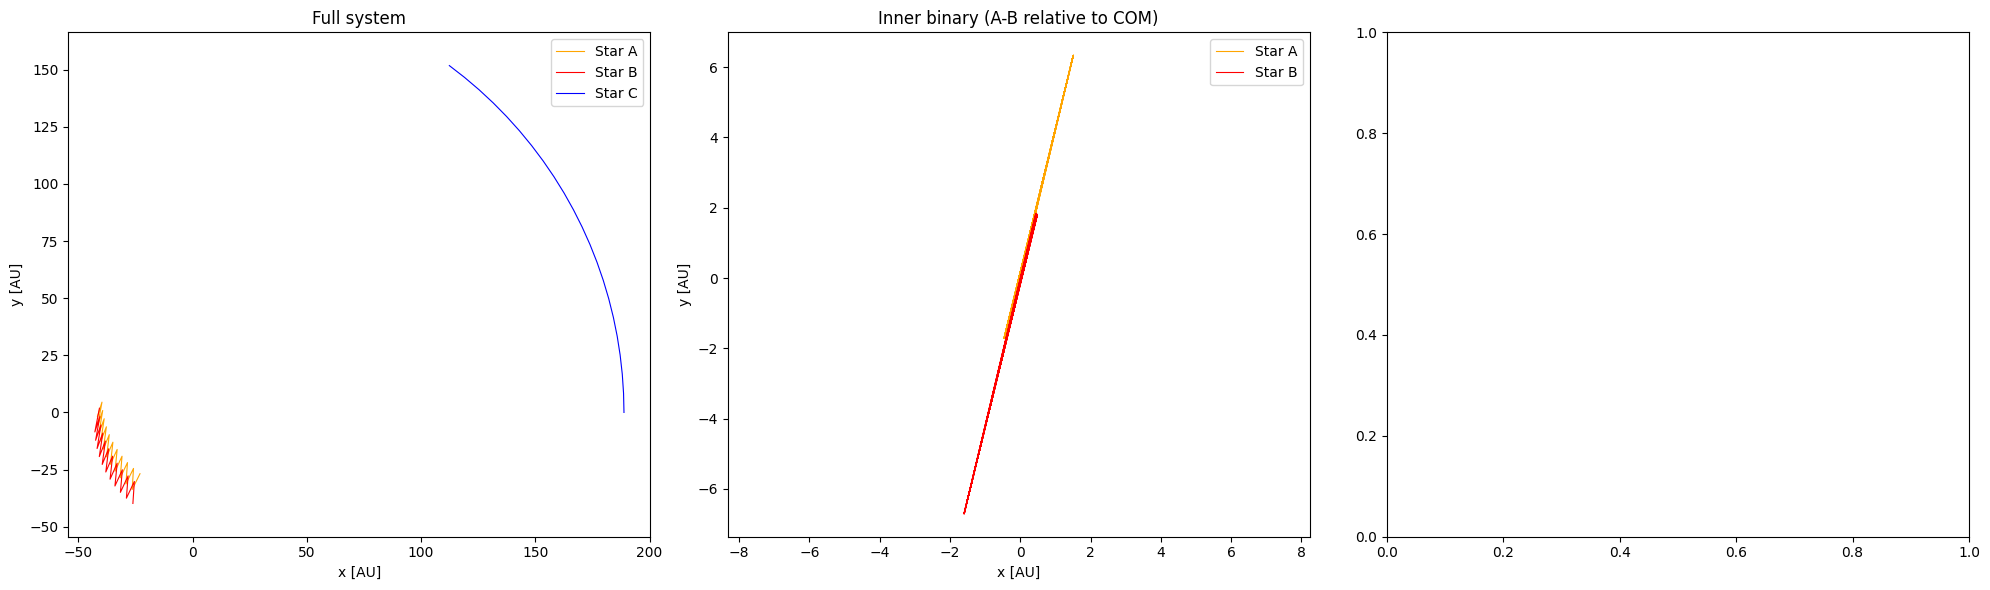

t range: 0.000 -> 394.095 yr,  steps: 22,  stars: 3,  planets: 0


In [63]:
H5_PATH = result

with h5py.File(H5_PATH, "r") as f:
    keys = sorted(
        [k for k in f.keys() if k.startswith("Step_")],
        key=lambda s: int(s.split("_")[1])
    )
    t_list, pos_list, mass_list, ptype_list = [], [], [], []
    for k in keys:
        g = f[k]
        t_list.append(g["time"][:])
        pos_list.append(g["pos"][:])
        mass_list.append(g["mass"][:])
        ptype_list.append(g["ptype"][:])

t     = np.concatenate(t_list)
pos   = np.concatenate(pos_list)
mass  = np.concatenate(mass_list)
ptype = np.concatenate(ptype_list)

n_particles = mass.shape[1]
if pos.ndim == 2:
    pos = pos.reshape(pos.shape[0], n_particles, 3)

star_idx   = np.where(ptype[0] == 0)[0]
planet_idx = np.where(ptype[0] == 1)[0]
m0 = mass[0]

iA, iB = star_idx[0], star_idx[1]
iC = star_idx[2] if len(star_idx) > 2 else None
mA, mB = m0[iA], m0[iB]
r_com_bin = (mA * pos[:, iA, :] + mB * pos[:, iB, :]) / (mA + mB)

star_colors = {0: 'orange', 1: 'red', 2: 'blue'}
star_labels = {0: 'A', 1: 'B', 2: 'C'}
planet_colors = plt.cm.Greens(np.linspace(0.4, 0.9, max(len(planet_idx), 1)))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: full system ---
ax = axes[0]
ax.set_title("Full system")
for i in star_idx:
    mask = np.isfinite(pos[:, i, 0])
    ax.plot(pos[mask, i, 0], pos[mask, i, 1],
            label=f"Star {star_labels.get(i, i)}", color=star_colors.get(i, 'gray'), lw=0.8)
for j, i in enumerate(planet_idx):
    mask = np.isfinite(pos[:, i, 0])
    ax.plot(pos[mask, i, 0], pos[mask, i, 1],
            label=f"Planet {j}", color=planet_colors[j], lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

# --- Plot 2: inner binary (A & B relative to their COM) ---
ax = axes[1]
ax.set_title("Inner binary (A-B relative to COM)")
for i in [iA, iB]:
    mask = np.isfinite(pos[:, i, 0])
    ax.plot(pos[mask, i, 0] - r_com_bin[mask, 0],
            pos[mask, i, 1] - r_com_bin[mask, 1],
            label=f"Star {star_labels.get(i, i)}", color=star_colors.get(i, 'gray'), lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

# --- Plot 3: planets relative to host star ---
ax = axes[2]
# find host star: nearest star to first planet at t=0
if len(planet_idx) > 0:
    dists_to_stars = [np.linalg.norm(pos[0, planet_idx[0], :] - pos[0, s, :]) for s in star_idx]
    host_idx = star_idx[np.argmin(dists_to_stars)]
    ax.set_title(f"Planets relative to Star {star_labels.get(host_idx, host_idx)}")
    ax.plot(0, 0, '*', color=star_colors.get(host_idx, 'gray'), ms=15,
            label=f"Star {star_labels.get(host_idx, host_idx)}")
    for j, i in enumerate(planet_idx):
        mask = np.isfinite(pos[:, i, 0])
        ax.plot(pos[mask, i, 0] - pos[mask, host_idx, 0],
                pos[mask, i, 1] - pos[mask, host_idx, 1],
                label=f"Planet {j}", color=planet_colors[j], lw=0.8)
    ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
    ax.axis("equal"); ax.legend()

plt.tight_layout()
plt.show()

print(f"t range: {t[0]:.3f} -> {t[-1]:.3f} yr,  steps: {len(t)},  "
      f"stars: {len(star_idx)},  planets: {len(planet_idx)}")
